In [1]:
import sys
!{sys.executable} -m pip install pandas matplotlib seaborn numpy


[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## Verificación de H2 — Estacionalidad de ventas

**Hipótesis:** el volumen de ventas presenta una **estacionalidad positiva marcada** en determinados meses del año.

**Criterio de verificación:**
1. Calcular ventas mensuales (€ y nº de operaciones) sobre los 24 meses del periodo (mayo-2024 → abril-2026).
2. Construir un **índice de estacionalidad por mes del año** agregando los datos de ambos años: índice = ventas del mes / media mensual × 100. Un valor de 100 = media, >100 = pico, <100 = valle.
3. Cuantificar el **spread pico/valle** y los meses extremos.

A continuación se realiza la carga, limpieza y la gráfica de ventas mensuales cronológicas. El cálculo del índice estacional y el veredicto vienen al final.

In [ ]:
# Imports y utilidades centralizadas
import sys, os
from pathlib import Path

repo_roots = [
    Path.cwd(),
    Path.cwd().parent,
    Path.cwd() / 'src',
    Path.cwd().parent / 'src',
]

data_dir = next((root / 'data' for root in repo_roots if (root / 'data').exists()), None)
utils_dir = next((root / 'utils' for root in repo_roots if (root / 'utils').exists()), None)

if data_dir is None:
    raise FileNotFoundError(
        "No se encontró la carpeta de datos. Rutas probadas: "
        + ", ".join(str(root / 'data') for root in repo_roots)
    )
if utils_dir is None:
    raise FileNotFoundError(
        "No se encontró la carpeta de utils. Rutas probadas: "
        + ", ".join(str(root / 'utils') for root in repo_roots)
    )

sys.path.insert(0, str(utils_dir.resolve()))

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

from funciones import (limpiar_nombres_columnas, limpiar_moneda,
                       mapear_si_no, anonimizar, parsear_mes_es)

# --- Carga de datos ---
# skiprows=1 porque los CSV traen una fila de título arriba
df_ventas   = pd.read_csv(data_dir / 'informe_ventas.csv',   skiprows=1)
df_reservas = pd.read_csv(data_dir / 'informe_reservas.csv', skiprows=1)

# --- Normalización de nombres de columnas ---
df_ventas   = limpiar_nombres_columnas(df_ventas)
df_reservas = limpiar_nombres_columnas(df_reservas)

# --- Limpieza monetaria (formato europeo "1.200,50 €" → 1200.50) ---
col_dinero_reservas = [c for c in df_reservas.columns
                       if 'total' in c or 'pagado' in c][0]
df_ventas['neto']              = df_ventas['neto'].apply(limpiar_moneda)
df_reservas['total_a_recibir'] = df_reservas[col_dinero_reservas].apply(limpiar_moneda)

# --- Fechas: "DD/MM/YYYY a las HH:MM" → datetime ---
df_ventas['fecha_creacion'] = pd.to_datetime(
    df_ventas['creado_el'].astype(str).str.replace(' a las ', ' ', regex=False),
    errors='coerce')

# --- Reprogramado: Sí/No → 1/0 ---
df_ventas['reprogramado'] = mapear_si_no(df_ventas['reprogramacion']).fillna(0).astype(int)

# --- Gráfico de ventas mensuales cronológicas ---
df_v_clean = df_ventas.dropna(subset=['fecha_creacion', 'neto'])
ventas_mensuales = (df_v_clean.groupby(df_v_clean['fecha_creacion'].dt.to_period('M'))
                              ['neto'].sum())
ventas_mensuales.index = ventas_mensuales.index.astype(str)

plt.figure(figsize=(12, 5))
ventas_mensuales.plot(kind='line', marker='o', color='teal', linewidth=2)
plt.title('Ventas mensuales — Spa Oasis (mayo-2024 → abril-2026)', fontsize=14)
plt.ylabel('Euros (€)')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()

os.makedirs('../img', exist_ok=True)
plt.savefig('../img/01_limpieza_y_estacionalidad.png')
plt.show()

print(f"Fechas válidas procesadas: {df_ventas['fecha_creacion'].notna().sum():,}")

FileNotFoundError: [Errno 2] No such file or directory: '../data/informe_ventas.csv'

In [ ]:
# Anonimización
# email -> cliente_id (entero) | CP -> cp_area (3 dígitos, solo provincias ES válidas)
df_ventas, df_reservas = anonimizar(df_ventas, df_reservas)
print("Anonimización aplicada. Columnas df_ventas:", df_ventas.columns.tolist())

Anonimización aplicada. Columnas df_ventas: ['producto', 'mes_del_pago', 'creado_el', 'tipo_de_pago', 'cargo_de_gestion', 'neto', 'id_de_reserva', 'reprogramacion', 'pais_del_telefono', 'fecha_creacion', 'reprogramado', 'cliente_id', 'cp_area']


=== Índice de estacionalidad (100 = media mensual) ===
mes_nombre  ventas_eur  n_ops  indice
   January   134949.64   1141   167.1
  February   107694.25    893   133.4
     March    87087.67    755   107.9
     April    82695.72    678   102.4
       May    51350.17    480    63.6
      June    54395.43    508    67.4
      July    53033.16    480    65.7
    August    58810.44    482    72.8
 September    70692.54    614    87.6
   October    89351.91    690   110.7
  November    76407.08    622    94.6
  December   102422.19    842   126.9

Pico:     January  (índice 167.1)
Valle:        May  (índice 63.6)
Spread pico/valle: 2.63×


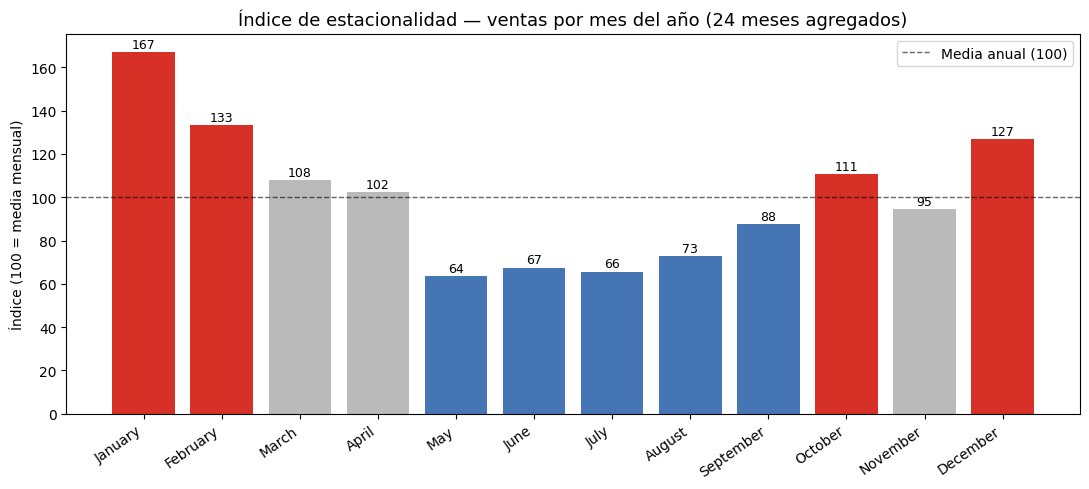

In [ ]:
# Índice de estacionalidad por mes del año (agregando ambos años)
# Permite ver el patrón anual estable más allá del crecimiento entre 2024 y 2026.

# Parseamos mes_del_pago ("January 2026") al mes calendario
df_ventas['mes_dt']     = parsear_mes_es(df_ventas['mes_del_pago'])
df_ventas['mes_num']    = df_ventas['mes_dt'].dt.month
df_ventas['mes_nombre'] = df_ventas['mes_dt'].dt.strftime('%B')

estacion = (df_ventas.dropna(subset=['mes_dt', 'neto'])
                     .groupby(['mes_num', 'mes_nombre'])
                     .agg(ventas_eur=('neto', 'sum'),
                          n_ops=('neto', 'count'))
                     .reset_index().sort_values('mes_num'))

media_mensual = estacion['ventas_eur'].mean()
estacion['indice'] = (estacion['ventas_eur'] / media_mensual * 100).round(1)

print("=== Índice de estacionalidad (100 = media mensual) ===")
print(estacion[['mes_nombre', 'ventas_eur', 'n_ops', 'indice']].to_string(index=False))
print()
pico  = estacion.loc[estacion['indice'].idxmax()]
valle = estacion.loc[estacion['indice'].idxmin()]
print(f"Pico:  {pico['mes_nombre']:>10s}  (índice {pico['indice']})")
print(f"Valle: {valle['mes_nombre']:>10s}  (índice {valle['indice']})")
print(f"Spread pico/valle: {pico['indice']/valle['indice']:.2f}×")

# Gráfico del índice estacional
plt.figure(figsize=(11, 5))
colores = ['#d73027' if v >= 110 else '#4575b4' if v <= 90 else '#bababa'
           for v in estacion['indice']]
bars = plt.bar(estacion['mes_nombre'], estacion['indice'], color=colores)
plt.axhline(100, color='black', linewidth=1, linestyle='--', alpha=0.6,
            label='Media anual (100)')
plt.title('Índice de estacionalidad — ventas por mes del año (24 meses agregados)',
          fontsize=13)
plt.ylabel('Índice (100 = media mensual)')
plt.xticks(rotation=35, ha='right')
plt.legend(loc='upper right')
for bar, v in zip(bars, estacion['indice']):
    plt.text(bar.get_x() + bar.get_width() / 2, v + 2, f'{v:.0f}',
             ha='center', fontsize=9)
plt.tight_layout()
plt.savefig('../img/01_indice_estacionalidad.png', dpi=200)
plt.show()

### Veredicto H2 — **CONFIRMADA**

**Resumen cuantitativo (índice de estacionalidad, 100 = media mensual):**

| Tramo | Meses | Índice |
|---|---|---|
| 🔴 **Pico** | **Enero** | **167** |
| 🔴 Alta | Febrero · Diciembre | 133 · 127 |
| ⚪ Estable | Octubre · Marzo · Abril | 111 · 108 · 102 |
| ⚪ Baja | Noviembre · Septiembre · Agosto | 95 · 88 · 73 |
| 🔵 **Valle** | Junio · Julio · **Mayo** | 67 · 66 · **64** |

- **Spread pico/valle:** **2,6×** (enero vende 2,6 veces más que mayo).
- **Trimestre fuerte:** Q4 + enero-febrero (Black Friday, Navidad, Reyes, San Valentín).
- **Trimestre débil:** mayo-agosto (verano andaluz: el cliente local prioriza playa / aire libre frente al spa).

**Interpretación:**

1. La estacionalidad **se confirma con fuerza**: el patrón se repite en los dos años del periodo y el spread es muy superior al ruido natural mes a mes.
2. El patrón es **contraintuitivo** para un spa de Sevilla: los meses más calurosos (mayo-agosto) son los más débiles, no los más fuertes. Coherente con un público **mayoritariamente local andaluz** (ver H1) que en verano busca otras opciones de ocio.
3. El pico de enero (167) está claramente impulsado por dos efectos solapados: (a) **canje** de tarjetas regalo compradas en navidad, y (b) cierre de campañas de regalo de Reyes y San Valentín. Coherente con el patrón observado en H3 (la *Tarjeta de regalo* es el producto líder en diciembre y enero).

**Implicación de negocio:**
- **Aprovechar el pico (nov-feb):** asegurar capacidad, dotación de personal y stock de tarjetas regalo. Es el momento natural para campañas de adquisición.
- **Activar el valle (may-ago):** diseñar promociones específicas para residentes durante el verano (descuentos, packs evening, tratamientos refrescantes). El gap entre mayo y enero (×2,6) es la mayor palanca de crecimiento del negocio.